C:\Users\Admin\AppData\Local\Temp\ipykernel_5868\2619365777.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1 0 1 1 1 0 1 0 1 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 1 0 1 1 0 0 1 0 1 1
 1 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 0 0 1 1 0
 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df.loc[mask_men_A, 'Driver_License'] = np.random.choice(



Synthetic data with 500 samples saved to 'driver_license_data.csv'

--- Sample of Loaded Data from CSV ---
  Gender    Group  Driver_License
0    Men  Group C               0
1  Women  Group A               1
2  Women  Group B               1
3    Men  Group B               1
4  Women  Group A               0

--- Proportion with Driver's License by Group and Gender ---
Gender    Men  Women
Group               
Group A  0.68   0.57
Group B  0.57   0.48
Group C  0.53   0.29


C:\Users\Admin\AppData\Local\Temp\ipykernel_5868\2619365777.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_5868\2619365777.py:48: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


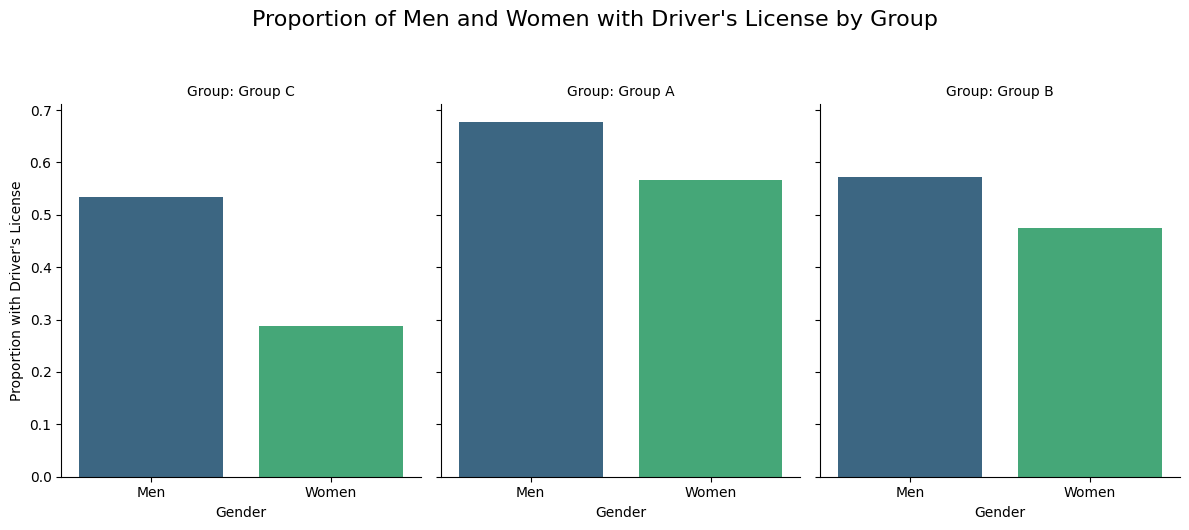

In [10]:
# Nguyễn Hoàng Tùng

import pandas as pd  # Manipulating tabular data
import numpy as np   # Numerical operations
import seaborn as sns  # Statistical data visualization
import matplotlib.pyplot as plt  # Plotting charts

# 1. Generate Synthetic Data
genders = ['Men', 'Women']
groups = ['Group A', 'Group B', 'Group C']
num_samples = 500

# Base random dataset
data = {
    'Gender': np.random.choice(genders, num_samples),
    'Group': np.random.choice(groups, num_samples),
    'Driver_License': np.random.randint(0, 2, num_samples)  # 0 = No, 1 = Yes
}
df = pd.DataFrame(data)

# Adjust probabilities for more interesting patterns
# Men in Group A → 75% chance to have a license
mask_men_A = (df['Gender'] == 'Men') & (df['Group'] == 'Group A')
df.loc[mask_men_A, 'Driver_License'] = np.random.choice(
    [0, 1], size=mask_men_A.sum(), p=[0.25, 0.75]
)

# Women in Group C → 30% chance to have a license
mask_women_C = (df['Gender'] == 'Women') & (df['Group'] == 'Group C')
df.loc[mask_women_C, 'Driver_License'] = np.random.choice(
    [0, 1], size=mask_women_C.sum(), p=[0.7, 0.3]
)

# 2. Save & Load Data
csv_filename = "driver_license_data.csv"
df.to_csv(csv_filename, index=False)
print(f"\nSynthetic data with {num_samples} samples saved to '{csv_filename}'")

loaded_df = pd.read_csv(csv_filename)
print("\n--- Sample of Loaded Data from CSV ---")
print(loaded_df.head())

# 3. Show Proportions
print("\n--- Proportion with Driver's License by Group and Gender ---")
print(loaded_df.groupby(['Group', 'Gender'])['Driver_License'].mean().unstack().round(2))

# 4. Plot Visualization
g = sns.catplot(
    x="Gender",
    y="Driver_License",
    col="Group",
    data=loaded_df,
    kind="bar",
    ci=None,
    aspect=0.8,
    palette="viridis"
)

g.set_axis_labels("Gender", "Proportion with Driver's License")
g.set_titles("Group: {col_name}")
g.fig.suptitle("Proportion of Men and Women with Driver's License by Group", y=1.05, fontsize=16)

plt.tight_layout()
plt.show()
